# Notebook 2 — Time Series Decomposition & Trend Analysis

**Project:** E-Commerce Retail & Fulfillment Analytics — an Amazon Retail / Operations analog
built on the Olist Brazilian e-commerce dataset (Sep-2016 – Oct-2018).

## Where this fits in the project

Notebook 1 profiled the dataset's distributions, missingness, and bivariate/multivariate
relationships, and cross-referenced the SQL revenue-growth catalog (`sql/analytics/01_revenue_growth.sql`,
Q1.1/Q1.2/Q1.7). Those SQL queries already established that GMV grew strongly from a
Jan-2017 ramp-up through a Mar–May 2018 plateau (~R$1.15M/month), with a single
Black-Friday-driven spike in Nov-2017 (+64% vs. its trailing 3-month average).

**This notebook goes deeper on the time dimension specifically**: it builds proper daily
and monthly time series, decomposes them into trend/seasonal/residual components, tests
their statistical properties (stationarity, autocorrelation), and produces a short-horizon
forecast. Along the way, **a naive forecast initially suggested GMV was declining through
mid-2018** — Section 2 investigates this claim in depth and finds it is substantially a
data-extract artifact, not a real business trend. This kind of "the model says X, but is
the *input data* trustworthy?" check is exactly the due diligence a senior analyst applies
before handing a forecast to stakeholders.

| # | Notebook | Focus |
|---|---|---|
| 1 | `01_data_profiling_and_eda.ipynb` | Profiling, missingness, univariate/bivariate/multivariate EDA |
| 2 | `02_time_series_decomposition.ipynb` (this notebook) | Trend/seasonality decomposition of orders & revenue |
| 3 | `03_geospatial_analysis.ipynb` | State-level choropleth — revenue, delivery time, satisfaction |
| 4 | `04_hypothesis_testing.ipynb` | Formal statistical tests — delivery delay vs. review score, category/region effects |
| 5 | `05_customer_segmentation.ipynb` | RFM + K-means clustering, segment profiles |
| 6 | `06_predictive_modeling.ipynb` | Logistic regression — late-delivery & low-review risk |

## Roadmap for this notebook

1. Building the Time Series (daily & monthly)
2. Is the Jun–Aug 2018 "Decline" Real? Investigating Right-Censoring
3. Day-of-Week Seasonality
4. Monthly Trend & STL Decomposition
5. Autocorrelation Structure (Daily)
6. Quantifying the Growth Trend
7. Short-Horizon Forecast (Holt-Winters)
8. Key Findings Summary

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from etl.db import get_engine

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

engine = get_engine()
print("Connected to:", engine.url.render_as_string(hide_password=True))

Connected to: postgresql+psycopg2://akhileshvangala@localhost:5432/olist_analytics


## 1. Building the Time Series

We start from `marts.fact_orders`, grouping by `order_purchase_date` and excluding
`canceled`/`unavailable` orders (the same filter SQL Q1.1–Q1.7 use), giving a daily series
of order counts and GMV. `asfreq("D")` reindexes to a continuous daily calendar so any
gaps become explicit (rather than silently skipped).

In [2]:
daily_full = pd.read_sql("""
    SELECT order_purchase_date AS date, COUNT(*) AS n_orders, SUM(order_total_value) AS gmv
    FROM marts.fact_orders
    WHERE order_status NOT IN ('canceled','unavailable')
    GROUP BY 1 ORDER BY 1
""", engine, parse_dates=["date"]).set_index("date")

full = daily_full.asfreq("D")
print(f"Date range: {full.index.min().date()} to {full.index.max().date()}  ({len(full)} calendar days)")

zero = full[full["n_orders"].isna() | (full["n_orders"] == 0)]
print(f"Calendar days with zero non-canceled orders: {len(zero)}")
print(f"  - 2016 ramp-up cluster:   {zero.loc['2016-09-01':'2016-12-31'].index.min().date()} "
      f"to {zero.loc['2016-09-01':'2016-12-31'].index.max().date()}  "
      f"({len(zero.loc['2016-09-01':'2016-12-31'])} days)")
print(f"  - Early-2017 cluster:     {zero.loc['2017-01-01':'2017-01-31'].index.tolist()}")
print(f"  - 2018 extract-tail cluster: {[d.date() for d in zero.loc['2018-08-01':'2018-09-30'].index.tolist()]}")

full = full.fillna(0)
full.tail(8)

Date range: 2016-09-04 to 2018-09-03  (730 calendar days)
Calendar days with zero non-canceled orders: 116
  - 2016 ramp-up cluster:   2016-09-05 to 2016-12-31  (108 days)
  - Early-2017 cluster:     [Timestamp('2017-01-01 00:00:00'), Timestamp('2017-01-02 00:00:00'), Timestamp('2017-01-03 00:00:00'), Timestamp('2017-01-04 00:00:00')]
  - 2018 extract-tail cluster: [datetime.date(2018, 8, 30), datetime.date(2018, 8, 31), datetime.date(2018, 9, 1), datetime.date(2018, 9, 2)]


,n_orders,gmv
date,,
2018-08-27,66.00,"6,111.61"
2018-08-28,39.00,"4,121.22"
2018-08-29,11.00,"1,762.70"
2018-08-30,0.00,0.00
2018-08-31,0.00,0.00
2018-09-01,0.00,0.00
2018-09-02,0.00,0.00
2018-09-03,1.00,166.46


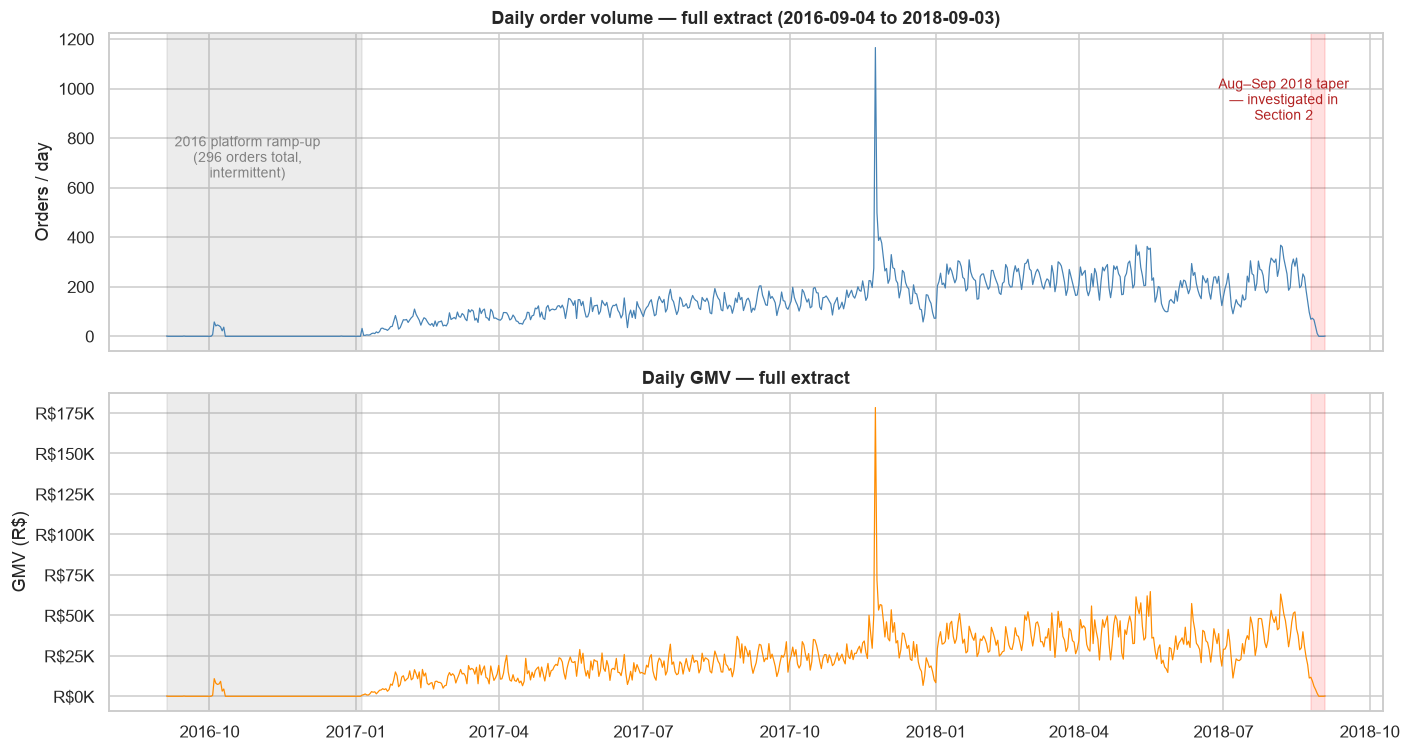

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(full.index, full["n_orders"], lw=0.8, color="steelblue")
axes[0].set_title("Daily order volume — full extract (2016-09-04 to 2018-09-03)")
axes[0].set_ylabel("Orders / day")

axes[1].plot(full.index, full["gmv"], lw=0.8, color="darkorange")
axes[1].set_title("Daily GMV — full extract")
axes[1].set_ylabel("GMV (R$)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}K"))

for ax in axes:
    ax.axvspan(pd.Timestamp("2016-09-04"), pd.Timestamp("2017-01-05"), color="grey", alpha=0.15)
    ax.axvspan(pd.Timestamp("2018-08-25"), pd.Timestamp("2018-09-03"), color="red", alpha=0.12)

ymax = full["n_orders"].max()
axes[0].annotate("2016 platform ramp-up\n(296 orders total,\nintermittent)",
                  xy=(pd.Timestamp("2016-10-25"), ymax * 0.55), fontsize=9, ha="center", color="grey")
axes[0].annotate("Aug–Sep 2018 taper\n— investigated in\nSection 2",
                  xy=(pd.Timestamp("2018-08-08"), ymax * 0.75), fontsize=9, ha="center", color="firebrick")

plt.tight_layout()
plt.show()

**Interpretation.** Two regions of the extract are visibly sparse:

- **Sep 2016 – early Jan 2017** (108 + 4 = 112 zero-order days, shaded grey): the platform's
  pilot phase, only 296 orders in all of 2016. SQL Q1.1–Q1.7 already exclude this period
  (analysis window starts 2017-01).
- **Late Aug – early Sep 2018** (shaded red): the *end* of the extract. Visually, daily
  order volume drops sharply in the last ~10 days, and Sep-2018 has only **1** non-canceled
  order in total. SQL's "ANALYSIS WINDOW NOTE" already flags Sep+Oct 2018 as out of scope —
  but it treats **Aug-2018 itself as part of the "first full, comparable 20-month window"**.

A naive look at monthly GMV shows Aug-2018 (R$996,974) *below* Jul-2018 (R$1,039,784),
continuing a dip that started in Jun-2018 — and a Holt-Winters model fit to this series
extrapolates that "decline" forward into a falling Sep–Nov 2018 forecast. **Before trusting
that forecast, Section 2 checks whether Aug-2018's reported total is even a reliable number
in the first place.**

## 2. Is the Jun–Aug 2018 "Decline" Real? Investigating Right-Censoring

The red-shaded region above is suspicious: a *real* demand slowdown should look like a
gradual decline across many months, not a cliff in the final ~10 days of the extract. The
standard diagnostic for "is this a trend or an artifact of the extract cutoff?" is to
compare the tail of the series against the *same calendar window one year earlier* — if
2017's Aug 13 – Sep 3 window looks "normal" while 2018's doesn't, the 2018 pattern is more
likely a data-collection artifact than a calendar-seasonal one.

In [4]:
window18 = full.loc["2018-08-13":"2018-09-03", ["n_orders", "gmv"]].reset_index()
window18["day_of_window"] = range(1, len(window18) + 1)

window17 = full.loc["2017-08-13":"2017-09-03", ["n_orders", "gmv"]].reset_index()
window17["day_of_window"] = range(1, len(window17) + 1)

cmp = window18.merge(window17, on="day_of_window", suffixes=("_2018", "_2017"))
cmp = cmp[["day_of_window", "date_2018", "n_orders_2018", "gmv_2018", "date_2017", "n_orders_2017", "gmv_2017"]]
cmp

,day_of_window,date_2018,n_orders_2018,gmv_2018,date_2017,n_orders_2017,gmv_2017
0,1,2018-08-13,287.00,"45,811.29",2017-08-13,91.00,"14,405.43"
1,2,2018-08-14,312.00,"51,280.42",2017-08-14,154.00,"21,275.26"
2,3,2018-08-15,283.00,"52,134.87",2017-08-15,193.00,"27,940.67"
3,4,2018-08-16,316.00,"41,691.66",2017-08-16,170.00,"25,056.39"
4,5,2018-08-17,254.00,"37,583.91",2017-08-17,155.00,"21,737.95"
5,6,2018-08-18,196.00,"28,698.10",2017-08-18,146.00,"20,025.87"
6,7,2018-08-19,204.00,"29,966.50",2017-08-19,107.00,"15,072.00"
7,8,2018-08-20,252.00,"39,851.87",2017-08-20,103.00,"14,955.17"
8,9,2018-08-21,239.00,"30,830.69",2017-08-21,177.00,"26,019.72"
9,10,2018-08-22,186.00,"24,262.61",2017-08-22,136.00,"19,749.47"


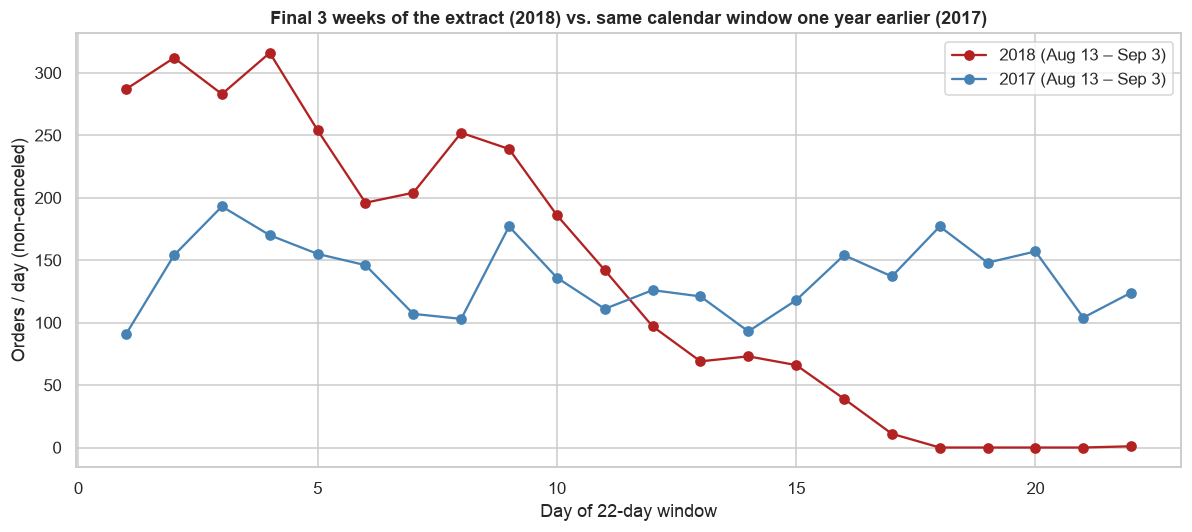

2018 window: mean=137.6, std=117.2, min=0.0, max=316.0
2017 window: mean=136.5, std=29.0, min=91.0, max=193.0


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cmp["day_of_window"], cmp["n_orders_2018"], marker="o", color="firebrick", label="2018 (Aug 13 – Sep 3)")
ax.plot(cmp["day_of_window"], cmp["n_orders_2017"], marker="o", color="steelblue", label="2017 (Aug 13 – Sep 3)")
ax.set_xlabel("Day of 22-day window")
ax.set_ylabel("Orders / day (non-canceled)")
ax.set_title("Final 3 weeks of the extract (2018) vs. same calendar window one year earlier (2017)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"2018 window: mean={cmp['n_orders_2018'].mean():.1f}, std={cmp['n_orders_2018'].std():.1f}, "
      f"min={cmp['n_orders_2018'].min()}, max={cmp['n_orders_2018'].max()}")
print(f"2017 window: mean={cmp['n_orders_2017'].mean():.1f}, std={cmp['n_orders_2017'].std():.1f}, "
      f"min={cmp['n_orders_2017'].min()}, max={cmp['n_orders_2017'].max()}")

The 2017 window oscillates around its mean with no end-of-window decay (it even rises
into early September). The 2018 window, by contrast, falls off a cliff after Aug 23:
287 → ... → 97 → 69 → 73 → 66 → 39 → **11** → (zero for 4 days) → **1**. This is not
calendar seasonality — it is concentrated in the *final* days of the extract regardless of
calendar position, the signature of a **right-censored extract**.

To understand the *mechanism*, look at `order_status` for every order placed on or after
Aug 25, 2018 (the start of the taper):

In [6]:
status_tail = pd.read_sql("""
    SELECT order_purchase_date::date AS purchase_date, order_status, COUNT(*) AS n
    FROM marts.fact_orders
    WHERE order_purchase_date >= '2018-08-25'
    GROUP BY 1, 2
    ORDER BY 1, 2
""", engine, parse_dates=["purchase_date"])

status_pivot = status_tail.pivot_table(index="purchase_date", columns="order_status", values="n", fill_value=0).astype(int)
status_pivot

order_status,canceled,delivered,shipped
purchase_date,,,
2018-08-25,0,69,0
2018-08-26,0,73,0
2018-08-27,1,66,0
2018-08-28,5,39,0
2018-08-29,3,11,0
2018-08-30,4,0,0
2018-08-31,1,0,0
2018-09-03,3,0,1
2018-09-06,3,0,0


**The mechanism is now clear.** Orders placed Aug 25–29 *do* appear — but only the
ones that had already reached `delivered` status by the time this extract was taken
(≈ early-to-mid Sep 2018, based on the trickle of `canceled` purchase dates running through
Oct-17). The median Olist delivery time is ~12 days (Notebook 1, Section 6), so an order
placed Aug 25 reaching `delivered` by Sep ~3 is on the *fast* tail of the delivery-time
distribution — these 69/73/66/39/11-order days are not "all orders placed that day", they
are **"the minority of that day's orders that happened to ship unusually fast"**. From
Aug 30 onward, essentially *no* order has had time to reach `delivered` at all — only a
handful of `canceled` orders (which don't require a delivery event) show up.

In other words: **this is not simple "missing data at random" — it is survivorship bias
toward the fastest-delivering orders, with the bias strength increasing the closer the
purchase date is to the extract date.** A day-count extrapolation is therefore a
conservative, first-order correction (it assumes Aug 1–24 is itself unbiased, which is
reasonable since even slow ~20-day deliveries from Aug 1–4 would have completed by
early September).

In [7]:
aug18 = full.loc["2018-08-01":"2018-08-31"]
aug18_first24 = full.loc["2018-08-01":"2018-08-24"]
jul18 = full.loc["2018-07-01":"2018-07-31"]

implied_orders = aug18_first24["n_orders"].sum() * 31 / 24
implied_gmv = aug18_first24["gmv"].sum() * 31 / 24

comparison = pd.DataFrame({
    "n_orders": [jul18["n_orders"].sum(), aug18["n_orders"].sum(), round(implied_orders)],
    "gmv":      [jul18["gmv"].sum(),      aug18["gmv"].sum(),      implied_gmv],
}, index=["Jul-2018 (actual, full month)",
          "Aug-2018 (actual, as reported — 29/31 days, last 5 tapering)",
          "Aug-2018 (implied — days 1-24 scaled x31/24)"])

jul_gmv = comparison.loc["Jul-2018 (actual, full month)", "gmv"]
comparison["gmv_vs_jul_pct"] = 100 * (comparison["gmv"] - jul_gmv) / jul_gmv
comparison

,n_orders,gmv,gmv_vs_jul_pct
"Jul-2018 (actual, full month)","6,233.00","1,039,783.58",0.00
"Aug-2018 (actual, as reported — 29/31 days, last 5 tapering)","6,421.00","996,973.51",-4.12
Aug-2018 (implied — days 1-24 scaled x31/24),"7,961.00","1,245,046.62",19.74


### Finding: the "decline" is substantially a data-extract artifact

| Estimate | Aug-2018 GMV | vs. Jul-2018 |
|---|---|---|
| **Reported (as-is in the extract)** | R$996,974 | **−4.1%** |
| **Implied (day-count extrapolation, days 1–24 × 31/24)** | R$1,245,047 | **+19.7%** |

These two numbers bracket the truth, and even the conservative end of that range
contradicts the "declining" narrative. The reported Aug-2018 total understates true demand
by roughly **R$248K (≈25%)** — and the corrected estimate would put Aug-2018 *above*
Jul-2018, not below it, i.e. **growth likely continued or resumed**, it did not reverse.

**Implication for the rest of this notebook:** any analysis that treats Aug-2018 as a
trustworthy month-end data point (trend regression, forecasting, decomposition) will be
distorted. From here on we define two windows:

- **"Complete window"** = Jan-2017 – Jul-2018 (19 months / 573 days, the last day with full,
  non-censored data) — used for STL decomposition and the daily ACF/PACF/ADF tests.
- **"Mature window"** = Jun-2017 – Jul-2018 (14 months) — used for trend regression and the
  Holt-Winters forecast, consistent with SQL Q1.7's choice to start the "mature" period in
  Jun-2017 (post-ramp-up, MoM growth settled below ~25%).

Section 7 returns to this finding and shows that a model-based forecast for Aug-2018,
estimated *without using any Aug-2018 data*, independently lands between these two
bookends — a third, fully independent line of evidence.

## 3. Day-of-Week Seasonality

Using the complete window (Jan-2017 – Jul-2018, with the first 4 days of Jan-2017 — which
have zero orders, part of the ramp-up tail — dropped to leave a gap-free 573-day series),
we compute the average orders/GMV for each day of the week.

Clean window: 2017-01-05 to 2018-07-31  (573 days, 0 gaps)


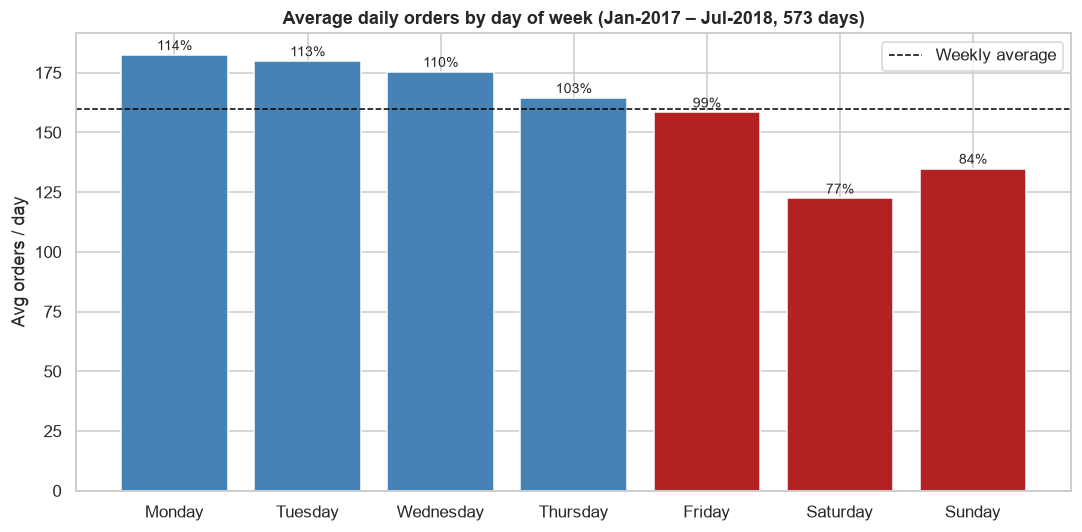

,,n_orders,gmv,pct_of_weekly_avg_orders
dow,dow_name,,,
0,Monday,182.45,"29,480.99",114.25
1,Tuesday,179.89,"28,867.42",112.65
2,Wednesday,175.42,"27,970.54",109.85
3,Thursday,164.45,"26,415.08",102.98
4,Friday,158.41,"25,913.91",99.20
5,Saturday,122.35,"19,786.45",76.62
6,Sunday,134.88,"21,013.22",84.46


In [8]:
clean = full.loc["2017-01-05":"2018-07-31"].copy()
print(f"Clean window: {clean.index.min().date()} to {clean.index.max().date()}  ({len(clean)} days, 0 gaps)")

clean["dow"] = clean.index.dayofweek
clean["dow_name"] = clean.index.day_name()
dow_summary = clean.groupby(["dow", "dow_name"])[["n_orders", "gmv"]].mean()
dow_summary["pct_of_weekly_avg_orders"] = 100 * dow_summary["n_orders"] / dow_summary["n_orders"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["firebrick" if v < 100 else "steelblue" for v in dow_summary["pct_of_weekly_avg_orders"]]
ax.bar(dow_summary.index.get_level_values("dow_name"), dow_summary["n_orders"], color=colors)
ax.axhline(dow_summary["n_orders"].mean(), color="black", ls="--", lw=1, label="Weekly average")
for i, (n, pct) in enumerate(zip(dow_summary["n_orders"], dow_summary["pct_of_weekly_avg_orders"])):
    ax.text(i, n + 2, f"{pct:.0f}%", ha="center", fontsize=9)
ax.set_title("Average daily orders by day of week (Jan-2017 – Jul-2018, 573 days)")
ax.set_ylabel("Avg orders / day")
ax.legend()
plt.tight_layout()
plt.show()

dow_summary.round(2)

**Interpretation.** A clean weekday-vs-weekend pattern: **Monday is the peak order day
(114% of the weekly average)**, with Tuesday and Wednesday close behind (113%, 110%), and
volume decays through the week to a **Saturday trough (77%)** before a partial Sunday
recovery (84%). This is the classic B2C e-commerce signature of browsing/buying behavior
concentrated around the work week (desk/desktop access, post-weekend catch-up) rather than
in-person retail's weekend peak.

**Operational read-through:** customer-service and fulfillment-ops staffing should be
weighted toward Mon–Wed, and any promotional calendar that assumes a "weekend sale" pattern
(common in US retail) may underperform here relative to a Monday or Tuesday placement —
worth a controlled test before committing budget.

## 4. Monthly Trend & STL Decomposition

We now move to monthly granularity and attempt a formal trend/seasonal/residual
decomposition — the natural next step after SQL Q1.7's trailing-3-month-average approach.

Complete window: 19 months (2017-01-01 to 2018-07-01)


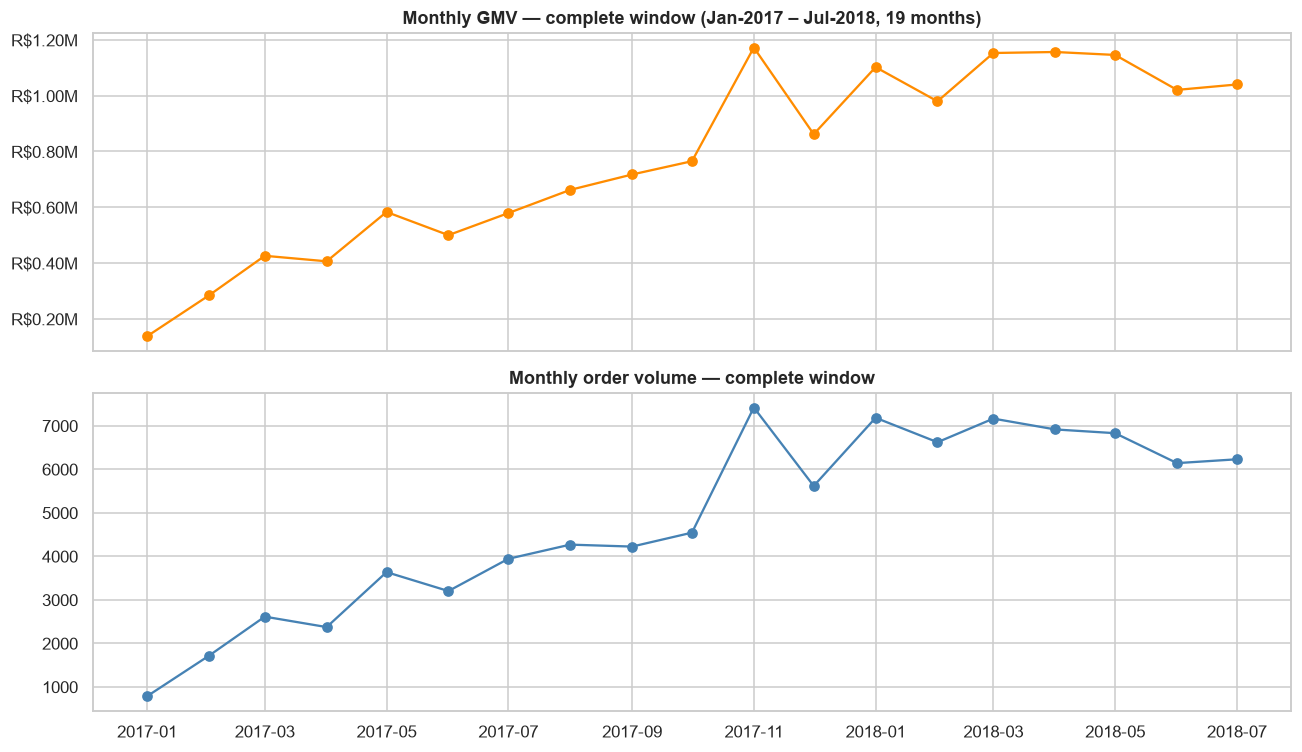

,n_orders,gmv
month,,
2017-01-01,787,"136,943.46"
2017-02-01,1718,"283,561.69"
2017-03-01,2617,"425,617.96"
2017-04-01,2377,"405,848.61"
2017-05-01,3640,"582,710.83"
2017-06-01,3205,"499,652.24"
2017-07-01,3946,"578,753.73"
2017-08-01,4272,"661,903.52"
2017-09-01,4227,"717,102.72"


In [9]:
monthly = pd.read_sql("""
    SELECT DATE_TRUNC('month', order_purchase_date)::date AS month,
           COUNT(*) AS n_orders, SUM(order_total_value) AS gmv
    FROM marts.fact_orders
    WHERE order_status NOT IN ('canceled','unavailable')
      AND order_purchase_date BETWEEN '2017-01-01' AND '2018-08-31'
    GROUP BY 1 ORDER BY 1
""", engine, parse_dates=["month"]).set_index("month")
monthly.index.freq = "MS"

complete = monthly.loc[:"2018-07-01"]  # 19 months — drop the censored Aug-2018 point
print(f"Complete window: {len(complete)} months ({complete.index.min().date()} to {complete.index.max().date()})")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(complete.index, complete["gmv"], marker="o", color="darkorange")
axes[0].set_title("Monthly GMV — complete window (Jan-2017 – Jul-2018, 19 months)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.2f}M"))
axes[1].plot(complete.index, complete["n_orders"], marker="o", color="steelblue")
axes[1].set_title("Monthly order volume — complete window")
plt.tight_layout()
plt.show()

complete

In [10]:
try:
    cd = seasonal_decompose(complete["gmv"], model="additive", period=12)
    print("Decomposition succeeded.")
except ValueError as e:
    print(f"ValueError: {e}")

ValueError: x must have 2 complete cycles requires 24 observations. x only has 19 observation(s)


**Interpretation.** Classical `seasonal_decompose` with `period=12` requires **2 full
annual cycles (24 months)** of data to estimate a seasonal component — we have 19. This is
a hard mathematical requirement (the algorithm averages each calendar month's values across
*at least two* occurrences), not a tunable parameter. **STL** (Seasonal-Trend decomposition
using LOESS, `robust=True`) has no such hard floor — it will run on any series — but as the
next cell shows, "runs without error" and "produces a trustworthy seasonal estimate" are
not the same thing when there's only 1.6 cycles of data.

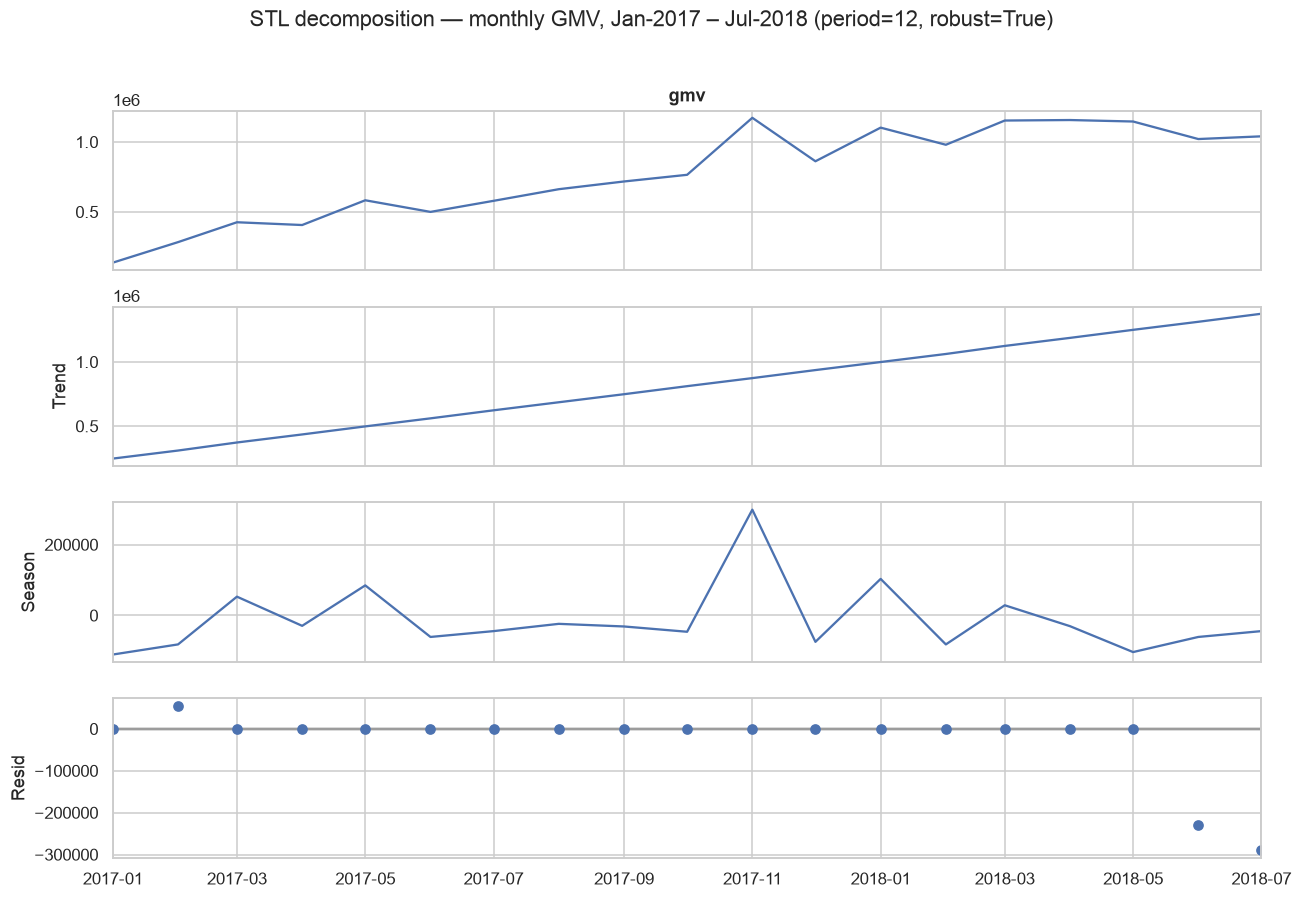

STL trend, Jul-2018:   R$1,374,505
Actual GMV, Jul-2018:  R$1,039,784
Trend overshoot:       +32.2%
Historical peak (Apr-2018 actual GMV): R$1,156,249

Nov-2017 seasonal term: R$+298,584  (+34.2% of trend)
Seasonal range (max-min) as % of mean trend: 50.4%


In [11]:
stl_res = STL(complete["gmv"], period=12, robust=True).fit()

fig = stl_res.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL decomposition — monthly GMV, Jan-2017 – Jul-2018 (period=12, robust=True)", y=1.02)
plt.tight_layout()
plt.show()

trend_jul18 = stl_res.trend.iloc[-1]
actual_jul18 = complete["gmv"].iloc[-1]
seasonal_nov17 = stl_res.seasonal.loc["2017-11-01"]
trend_nov17 = stl_res.trend.loc["2017-11-01"]

print(f"STL trend, Jul-2018:   R${trend_jul18:,.0f}")
print(f"Actual GMV, Jul-2018:  R${actual_jul18:,.0f}")
print(f"Trend overshoot:       {100*(trend_jul18-actual_jul18)/actual_jul18:+.1f}%")
print(f"Historical peak (Apr-2018 actual GMV): R${complete['gmv'].loc['2018-04-01']:,.0f}")
print()
print(f"Nov-2017 seasonal term: R${seasonal_nov17:+,.0f}  ({100*seasonal_nov17/trend_nov17:+.1f}% of trend)")
print(f"Seasonal range (max-min) as % of mean trend: {100*(stl_res.seasonal.max()-stl_res.seasonal.min())/stl_res.trend.mean():.1f}%")

**Critique — what STL gets right, and where it breaks down with < 2 cycles:**

- **What it gets right:** the seasonal component's single largest value, by a wide margin,
  is **Nov-2017 (+R$298,584, ~34% of trend level)**. This independently corroborates SQL
  Q1.7's finding that Nov-2017 (Black Friday, Nov 24 2017 in Brazil) was +64% above its
  trailing 3-month average — two completely different methods agree that **Nov-2017 is the
  one genuinely exceptional month** in this dataset.
- **What breaks down:** the *trend* component climbs smoothly to **R$1,374,505 by
  Jul-2018 — 32% above the actual Jul-2018 GMV (R$1,039,784), and even above the
  dataset's all-time peak month (Apr-2018, R$1,156,249)**. With only 1.6 annual cycles,
  STL has no second occurrence of any calendar month to check its seasonal estimates
  against, so it effectively has one free parameter per month to fit each point — Nov-2017's
  spike gets absorbed almost entirely into "seasonal" (residual ≈ 0), but in doing so it also
  pulls the surrounding months' seasonal terms sharply negative (Oct -R$46K, Dec -R$75K) to
  compensate, which then drags the *trend* curve upward to keep the fit smooth. The result
  is a trend line that is mathematically "smooth" but not a believable estimate of the
  current demand level.
- **A second anomaly, unrelated to the first:** even with that much flexibility, STL's
  fit still leaves two large negative residuals at the *very end* of the series —
  **Jun-2018 (-R$230,617) and Jul-2018 (-R$290,316)**, by far the largest residuals
  anywhere in the 19 months (every other month is within ±R$50K). Trend+seasonal alone
  cannot explain these two months even when given a free parameter per calendar month.
  This is a fourth independent signal (alongside the Section 6 regression residuals and
  the Section 7 forecast) that something genuinely unusual happened in Jun–Jul 2018 —
  Section 7 explores the FIFA World Cup as one candidate explanation.

**Conclusion:** STL is useful here as a **confirmatory cross-check** (it agrees Nov-2017 is
special) but its trend/seasonal split should **not** be used for forecasting or
de-seasonalizing this 19-month series. SQL Q1.7's trailing-3-month-average approach — simpler,
and validated against the same Nov-2017 anchor — remains the right tool until a 24+ month
extract is available.

## 5. Autocorrelation Structure (Daily)

Switching back to the daily series (complete window, 573 days), we test for stationarity
(Augmented Dickey-Fuller) and examine the autocorrelation (ACF) and partial autocorrelation
(PACF) functions for evidence of the weekly cycle found in Section 3.

In [12]:
adf_level = adfuller(clean["n_orders"], autolag="AIC")
print(f"ADF (level):     stat={adf_level[0]:.4f}, p-value={adf_level[1]:.4f}, lags={adf_level[2]}, nobs={adf_level[3]}")
print("Critical values:", {k: round(v, 3) for k, v in adf_level[4].items()})

diff = clean["n_orders"].diff().dropna()
adf_diff = adfuller(diff, autolag="AIC")
print(f"\nADF (1st diff):  stat={adf_diff[0]:.4f}, p-value={adf_diff[1]:.8f}, lags={adf_diff[2]}")

ADF (level):     stat=-2.7511, p-value=0.0656, lags=14, nobs=558
Critical values: {'1%': np.float64(-3.442), '5%': np.float64(-2.867), '10%': np.float64(-2.57)}

ADF (1st diff):  stat=-9.7725, p-value=0.00000000, lags=12


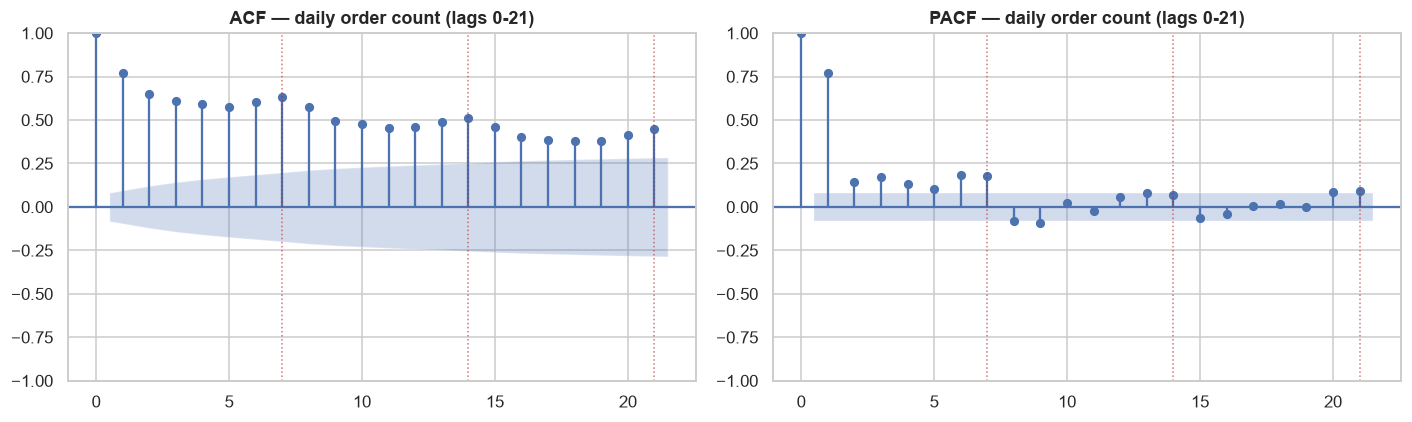

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(clean["n_orders"], lags=21, ax=axes[0])
axes[0].set_title("ACF — daily order count (lags 0-21)")
plot_pacf(clean["n_orders"], lags=21, ax=axes[1], method="ywm")
axes[1].set_title("PACF — daily order count (lags 0-21)")
for ax in axes:
    for lag in (7, 14, 21):
        ax.axvline(lag, color="firebrick", ls=":", lw=1, alpha=0.6)
plt.tight_layout()
plt.show()

**Interpretation.**

- **ADF level test:** stat=-2.75, p=0.066 — fails the 5% significance threshold but passes
  10%. This "borderline non-stationary" result is exactly what we'd expect from a series
  with a genuine upward trend (Section 6 quantifies it) superimposed on stationary
  day-to-day fluctuation.
- **ADF first-difference test:** stat=-9.77, p≈0 — overwhelmingly stationary. Differencing
  removes the trend, confirming the non-stationarity is trend-driven, not a structural
  issue with the series.
- **ACF:** decays slowly from 0.77 (lag 1) — typical of a trending series — but with local
  bumps at **lag 7 (0.635) and lag 14 (0.510)**, each a local peak relative to its
  immediate neighbors (lag 6: 0.601, lag 8: 0.573; lag 13: 0.489, lag 15: 0.459). These
  bumps are the autocorrelation signature of the weekly cycle quantified in Section 3.
- **PACF:** dominated by a lag-1 spike (0.77, the short-run persistence), but with a
  secondary bump at **lags 6-7 (both ≈0.185)** — a *direct* (partial) weekly effect after
  controlling for the intermediate days. This is independent statistical confirmation,
  via a completely different method, of the Monday-peak / Saturday-trough pattern found
  in Section 3.

## 6. Quantifying the Growth Trend

Using the **mature window** (Jun-2017 – Jul-2018, 14 months — post-ramp-up, and excluding
the censored Aug-2018 point), we fit both a linear and a log-linear (compound growth) trend
to monthly GMV.

Linear fit:     slope=R$45,954.88/month   intercept=R$619,296.93
                R²=0.6730   p-value=3.26e-04   (n=14)

Log-linear fit: slope=0.0567  =>  5.84% MoM compounding
                R²=0.6974   p-value=2.02e-04


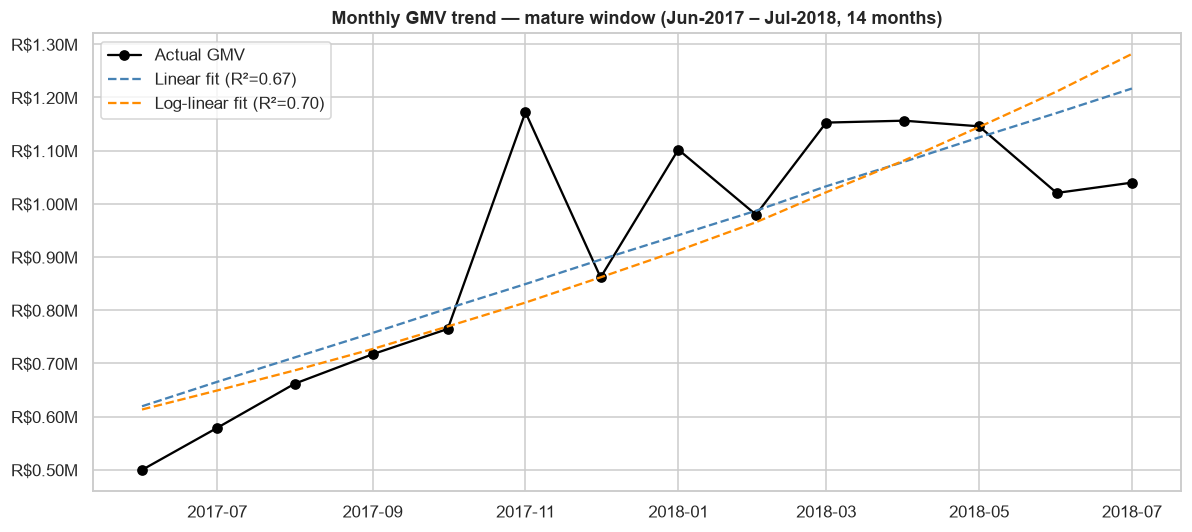

In [14]:
mature = monthly.loc["2017-06-01":"2018-07-01"].copy()
mature["t"] = np.arange(len(mature))

lin = stats.linregress(mature["t"], mature["gmv"])
log_lin = stats.linregress(mature["t"], np.log(mature["gmv"]))

print(f"Linear fit:     slope=R${lin.slope:,.2f}/month   intercept=R${lin.intercept:,.2f}")
print(f"                R²={lin.rvalue**2:.4f}   p-value={lin.pvalue:.2e}   (n={len(mature)})")
print()
print(f"Log-linear fit: slope={log_lin.slope:.4f}  =>  {100*(np.exp(log_lin.slope)-1):.2f}% MoM compounding")
print(f"                R²={log_lin.rvalue**2:.4f}   p-value={log_lin.pvalue:.2e}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(mature.index, mature["gmv"], marker="o", color="black", label="Actual GMV")
ax.plot(mature.index, lin.intercept + lin.slope * mature["t"], "--", color="steelblue",
        label=f"Linear fit (R²={lin.rvalue**2:.2f})")
ax.plot(mature.index, np.exp(log_lin.intercept + log_lin.slope * mature["t"]), "--", color="darkorange",
        label=f"Log-linear fit (R²={log_lin.rvalue**2:.2f})")
ax.set_title("Monthly GMV trend — mature window (Jun-2017 – Jul-2018, 14 months)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.2f}M"))
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.** Both fits are highly significant (p < 0.001) despite the small
sample (n=14):

- **Linear:** +R$45,955/month, R²=0.673 — over the 14-month window this implies total GMV
  grew by roughly R$643K (≈ the gap between the Jun-2017 and Jul-2018 fitted values).
- **Log-linear:** +5.84% compounding MoM, R²=0.697 — the slightly better fit suggests
  growth was *proportionally* faster early in the window (consistent with "off a smaller
  base") and decelerating in relative terms as GMV scaled up, even while absolute monthly
  gains stayed roughly constant — both descriptions are consistent with the same data.

The R² values (~0.67–0.70) leave a substantial ~30% of month-to-month variance
unexplained by a smooth trend — visible in the chart as Nov-2017's spike (above both
lines) and the Jun-2018 dip (below both lines). Section 7's forecast inherits this
residual uncertainty.

## 7. Short-Horizon Forecast (Holt-Winters)

We fit an additive-trend Exponential Smoothing model (Holt's linear trend method — no
seasonal component, since Section 4 established that a reliable seasonal estimate isn't
achievable with this much history) to the **mature window**, and forecast 4 months ahead
(Aug–Nov 2018). Critically, **Aug-2018 is *not* in the training data** — its forecast value
becomes a third, independent estimate to compare against Section 2's two bookends.

In [15]:
hw = ExponentialSmoothing(mature["gmv"], trend="add", seasonal=None, initialization_method="estimated").fit()
fcst = hw.forecast(4)
resid_std = (hw.fittedvalues - mature["gmv"]).std()

print(f"In-sample residual std: R${resid_std:,.2f}")
print()
for h, (idx, val) in enumerate(fcst.items(), start=1):
    se_h = resid_std * np.sqrt(h)
    print(f"{idx.date()}: point=R${val:,.0f}   approx. 95% CI = [R${val-1.96*se_h:,.0f}, R${val+1.96*se_h:,.0f}]")

In-sample residual std: R$133,369.89

2018-08-01: point=R$1,068,901   approx. 95% CI = [R$807,496, R$1,330,306]
2018-09-01: point=R$1,046,961   approx. 95% CI = [R$677,278, R$1,416,643]
2018-10-01: point=R$1,025,021   approx. 95% CI = [R$572,254, R$1,477,788]
2018-11-01: point=R$1,003,081   approx. 95% CI = [R$480,271, R$1,525,891]


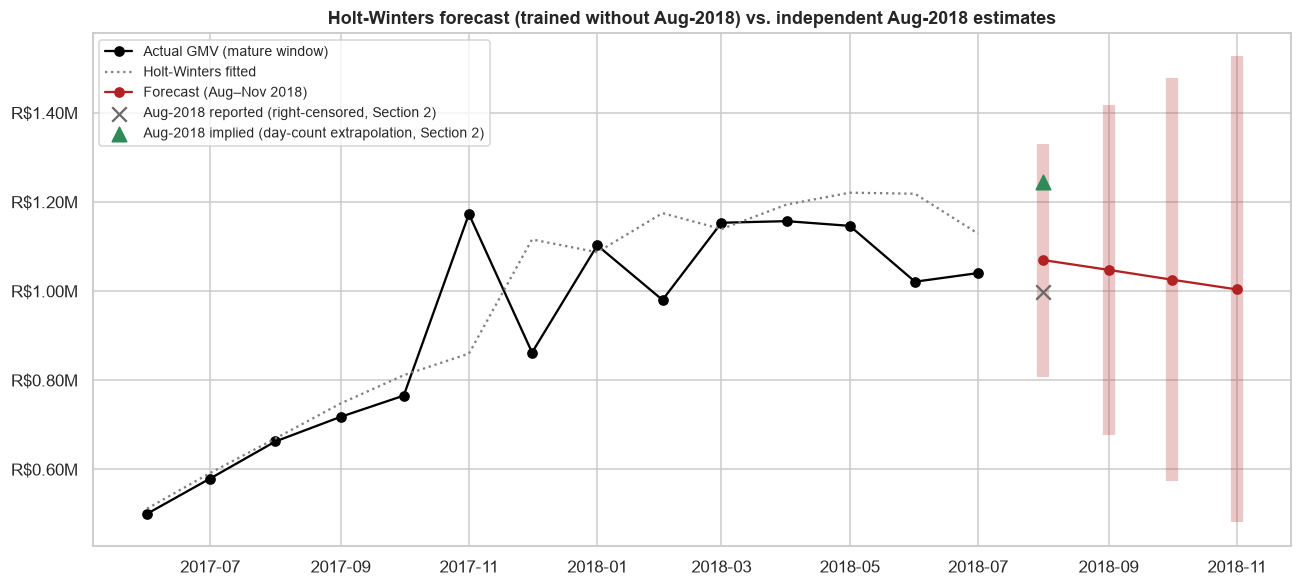

In [16]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(mature.index, mature["gmv"], marker="o", color="black", label="Actual GMV (mature window)")
ax.plot(mature.index, hw.fittedvalues, color="grey", ls=":", label="Holt-Winters fitted")
ax.plot(fcst.index, fcst.values, marker="o", color="firebrick", label="Forecast (Aug–Nov 2018)")

for h, (idx, val) in enumerate(fcst.items(), start=1):
    se_h = resid_std * np.sqrt(h)
    ax.plot([idx, idx], [val - 1.96 * se_h, val + 1.96 * se_h], color="firebrick", alpha=0.25, lw=8,
            solid_capstyle="butt")

ax.scatter([pd.Timestamp("2018-08-01")], [996973.51], color="dimgrey", marker="x", s=90, zorder=5,
           label="Aug-2018 reported (right-censored, Section 2)")
ax.scatter([pd.Timestamp("2018-08-01")], [1245046.62], color="seagreen", marker="^", s=90, zorder=5,
           label="Aug-2018 implied (day-count extrapolation, Section 2)")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.2f}M"))
ax.set_title("Holt-Winters forecast (trained without Aug-2018) vs. independent Aug-2018 estimates")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation and caveats.**

- **Triangulation on Aug-2018:** the model-based forecast (R$1,068,901) — produced *without
  any Aug-2018 data* — lands **between** the reported actual (R$996,974) and the day-count
  extrapolation (R$1,245,047), and **above the reported figure**. Three independent methods
  (SQL/extrapolation, time-series model, and the raw extract) now all point the same
  direction: **the as-reported Aug-2018 GMV understates the true value.** This is strong
  convergent evidence for Section 2's right-censoring finding.
- **The Sep–Nov 2018 forecast still declines** (R$1.047M → R$1.025M → R$1.003M). This is
  driven less by Aug-2018 (which isn't in the training data at all) and more by the
  **Jun-2018 dip** (-R$125,304 vs. May, -10.9%, with only a partial +R$19,401 recovery in
  Jul) pulling Holt's smoothed trend estimate negative. Notably, **Jun 14 – Jul 15, 2018
  was the FIFA World Cup** (Brazil was eliminated Jul 6) — a widely-discussed disruptor of
  Brazilian e-commerce activity. This is a **plausible hypothesis, not a verified
  conclusion** (no external benchmark data is joined here), but the timing alignment with
  Jul's partial recovery is suggestive.
- **The confidence intervals are very wide** (±R$350K for Sep-2018, widening to ±R$525K by
  Nov-2018, on a base of ~R$1M) — with only 14 monthly observations, this forecast is
  **directional, not decision-grade**.

**Recommendation:** do not present the Sep–Nov 2018 decline as a finding on its own. Instead:
(1) flag Aug-2018 as right-censored and exclude it from trend reporting until a later extract
with complete Sep–Oct 2018 data is available; (2) investigate the Jun-2018 dip against
external Brazilian e-commerce/World-Cup-period benchmarks before attributing it to anything
structural; (3) re-run this forecast once 2+ additional complete months are available — both
to extend the 14-month training window and to obtain an actual (not extrapolated) Aug-2018
value to validate against.

## 8. Key Findings Summary

Continuing the numbering from Notebook 1 (findings 1–14):

| # | Finding | Evidence | Cross-reference |
|---|---|---|---|
| 15 | **Day-of-week seasonality is strong and consistent**: Monday is the peak order day (114% of weekly avg), decaying through the week to a Saturday trough (77%) — a classic B2C "weekday browsing" pattern. | Section 3 | Ops staffing / promo calendar |
| 16 | **The apparent Jun–Aug 2018 GMV "decline" is substantially a right-censoring artifact**, not a genuine demand drop. Aug-2018 has data for only 29/31 days; the final 5 observed days taper sharply (69→11 orders/day) due to survivorship bias toward fast-delivering orders near the extract cutoff, while the same calendar window in Aug-2017 shows no such taper. | Section 2 | Refines SQL Q1.1/Q1.2/Q1.7's "2017-01..2018-08 complete window" framing |
| 17 | **Triangulation across 3 independent methods** — reported actual (R$0.997M) < Holt-Winters forecast (R$1.069M) < day-count extrapolation (R$1.245M) — all place true Aug-2018 GMV **above** the reported figure, i.e. growth likely continued past Jul-2018. | Sections 2 & 7 | Corroborates Finding 16 |
| 18 | **STL decomposition independently corroborates Nov-2017 as the dataset's one exceptional month** (+R$298,584 seasonal term, ~34% of trend — vs. SQL Q1.7's independently-derived +64% vs. trailing-avg), but with only 1.6 annual cycles its *trend* component overshoots actual Jul-2018 GMV by 32% — STL's trend/seasonal split should not be used for forecasting until a 24+ month extract is available. | Section 4 | Methodology note for future re-runs |
| 19 | **Daily order counts are borderline non-stationary in levels** (ADF p=0.066, reflecting the growth trend) and **strongly stationary after first-differencing** (p<0.0001); ACF/PACF show a secondary lag-7/14 weekly signature, independently confirming Finding 15 via a different statistical method. | Section 5 | Corroborates Finding 15 |
| 20 | The **mature-period (Jun-2017 – Jul-2018) growth trend** is well-approximated by ~R$45,955/month linear growth (R²=0.673) or ~5.84% compounding MoM (R²=0.697), both significant at p<0.001 despite n=14. | Section 6 | — |
| 21 | The **one-month Jun-2018 GMV dip** (-10.9% vs. May, partially recovering +1.9% in Jul) coincides with the 2018 FIFA World Cup (Jun 14 – Jul 15) — a plausible but **unverified** one-off demand disruptor; recommend validating against external benchmarks before attributing causally. | Section 7 | Flag for follow-up with external data |
| 22 | A **Holt-Winters forecast** (mature window, Aug-2018 excluded) projects Sep–Nov 2018 GMV of ~R$1.0–1.05M with very wide 95% CIs (±R$350K to ±R$525K) — directional only. Recommend re-running once complete Sep–Oct 2018 data is available. | Section 7 | — |

**Overall takeaway:** the marketplace's underlying growth trajectory through mid-2018 is
strong and statistically well-supported (Findings 18, 20). The most "alarming"-looking
signal in the raw data — a Jun–Aug 2018 decline that a naive forecast would extrapolate
into a falling Sep–Nov 2018 — does not survive due diligence: it is driven by a data-extract
artifact (Findings 16, 17) and a likely transitory external event (Finding 21), not a
structural slowdown. **This is the central methodological lesson of this notebook**: before
forecasting from the most recent data points in any extract, always check whether those
points are *complete*.